# LDDMM: how to estimate a deterministic atlas?

This is analog to a registration problem for multiple meshes.

For registration between two meshes check [LDDMM: how to register a mesh to a template?](./deformetrica_register_mesh_template.ipynb).

In [1]:
import shutil
import string

import numpy as np
import pyvista as pv

import polpo.utils as putils
from polpo.mesh.deformetrica import (
    DeterministicAtlasDir,
    FrechetMean,
    LddmmMetric,
    Point,
)
from polpo.mesh.generation.blob import create_blob
from polpo.plot.pyvista import RegisteredMeshesGifPlotter
from polpo.preprocessing.mesh.registration import RigidAlignment

[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.


In [2]:
RECOMPUTE = False

# NB: fix seed before setting it to False
np.random.seed(42)

STATIC_VIZ = True

if STATIC_VIZ:
    pv.set_jupyter_backend("static")

In [3]:
OUTPUTS_DIR = putils.get_results_path() / "deterministic_atlas_blob_example"

if OUTPUTS_DIR.exists() and RECOMPUTE:
    shutil.rmtree(OUTPUTS_DIR)


OUTPUTS_DIR.mkdir(exist_ok=True, parents=True)

## Generate meshes

In [4]:
n_meshes = 3
bump_amp = 0.2

raw_meshes = [
    create_blob(resolution=10, bump_amp=bump_amp, n_bumps=5, smoothing_iter=10)
    for _ in range(n_meshes)
]

raw_meshes[0].points.shape

(82, 3)

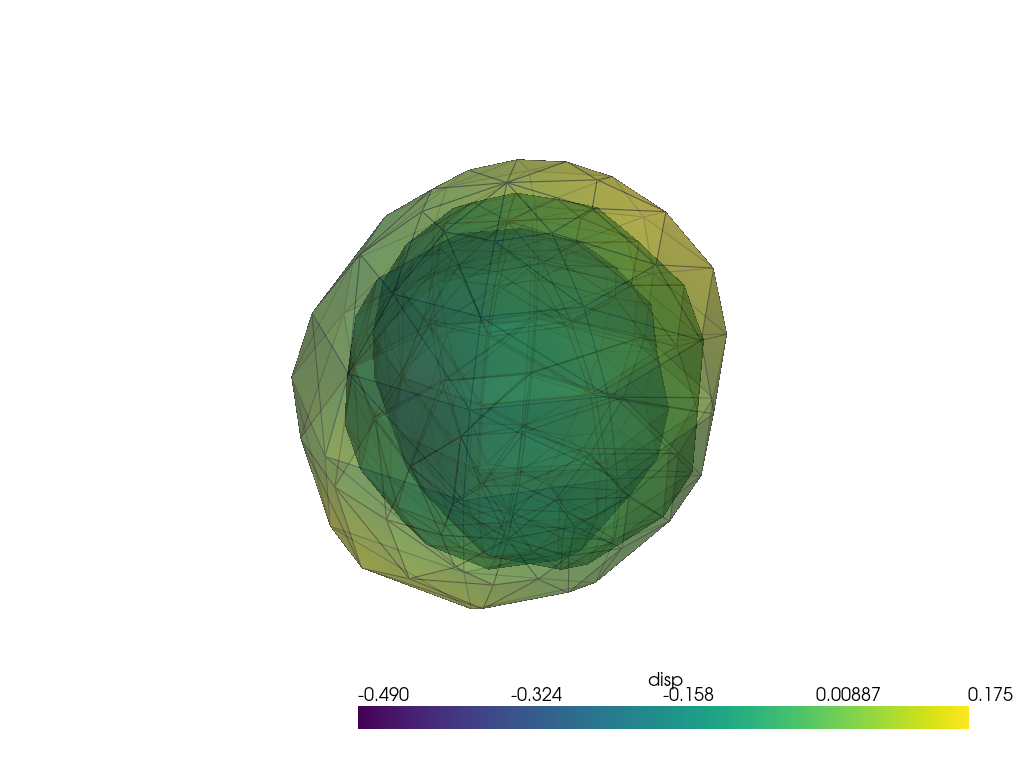

In [5]:
pl = pv.Plotter(border=False)

for mesh in raw_meshes:
    pl.add_mesh(mesh, show_edges=True, opacity=0.5)

pl.show()

In [6]:
prep_pipe = RigidAlignment(known_correspondences=True)

meshes = prep_pipe(raw_meshes)

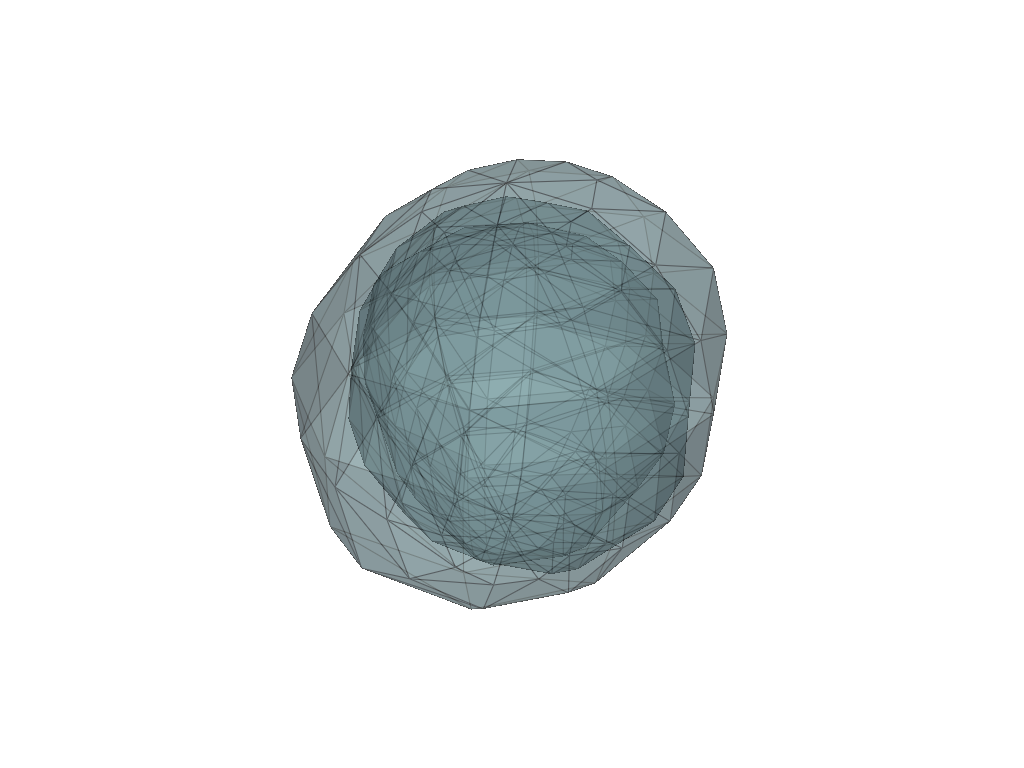

In [7]:
pl = pv.Plotter(border=False)

for mesh in meshes:
    pl.add_mesh(mesh, show_edges=True, opacity=0.5)

pl.show()

## Deterministic atlas

In [8]:
kernel_width = 2 * bump_amp
registration_kwargs = dict(
    kernel_width=kernel_width,
    regularisation=1.0,
    max_iter=2000,
    freeze_control_points=False,
    metric="varifold",
    tol=1e-16,
    attachment_kernel_width=bump_amp,
)

metric = LddmmMetric(OUTPUTS_DIR, **registration_kwargs)

In [9]:
dataset = [
    Point(id_=string.ascii_uppercase[index], pv_surface=mesh, dirname=metric.meshes_dir)
    for index, mesh in enumerate(meshes)
]

Use LDDMM to estimate the atlas.

In [10]:
estimator = FrechetMean(
    metric,
    initial_step_size=1e-1,
)

estimator.fit(dataset, atlas_id="atlas")

In [11]:
atlas = estimator.estimate_

atlas_dir = DeterministicAtlasDir.from_dirname(atlas.vtk_path.parent)

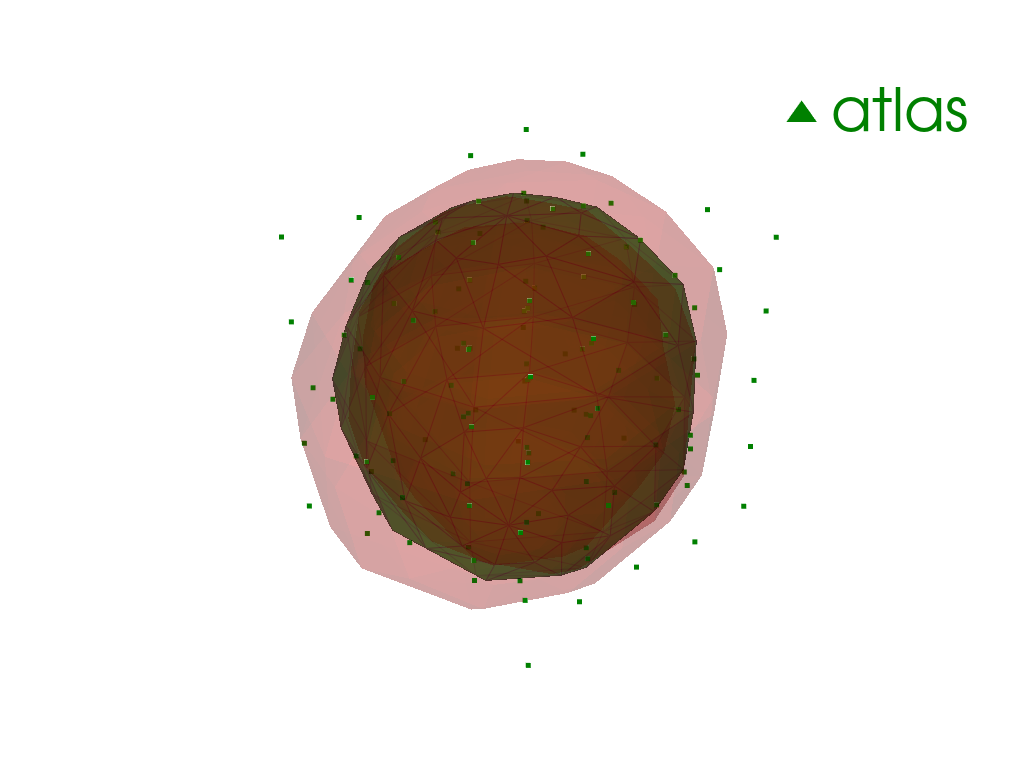

In [12]:
pl = pv.Plotter(border=False)

for point in atlas_dir.points:
    pl.add_mesh(point.as_pv(), opacity=0.2, color="red")

pl.add_mesh(
    atlas.as_pv(),
    show_edges=True,
    opacity=0.5,
    color="green",
    label="atlas",
)

pl.add_points(atlas_dir.control_points().as_pv(), color="green")
pl.add_legend()


pl.show()

Reconstruction

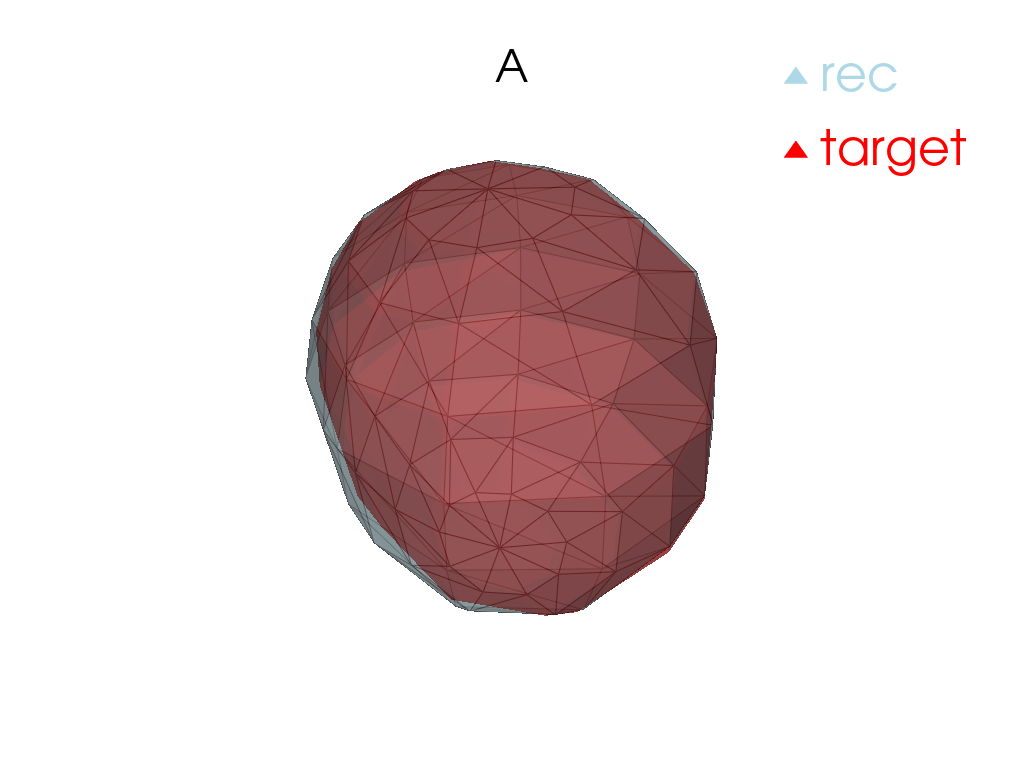

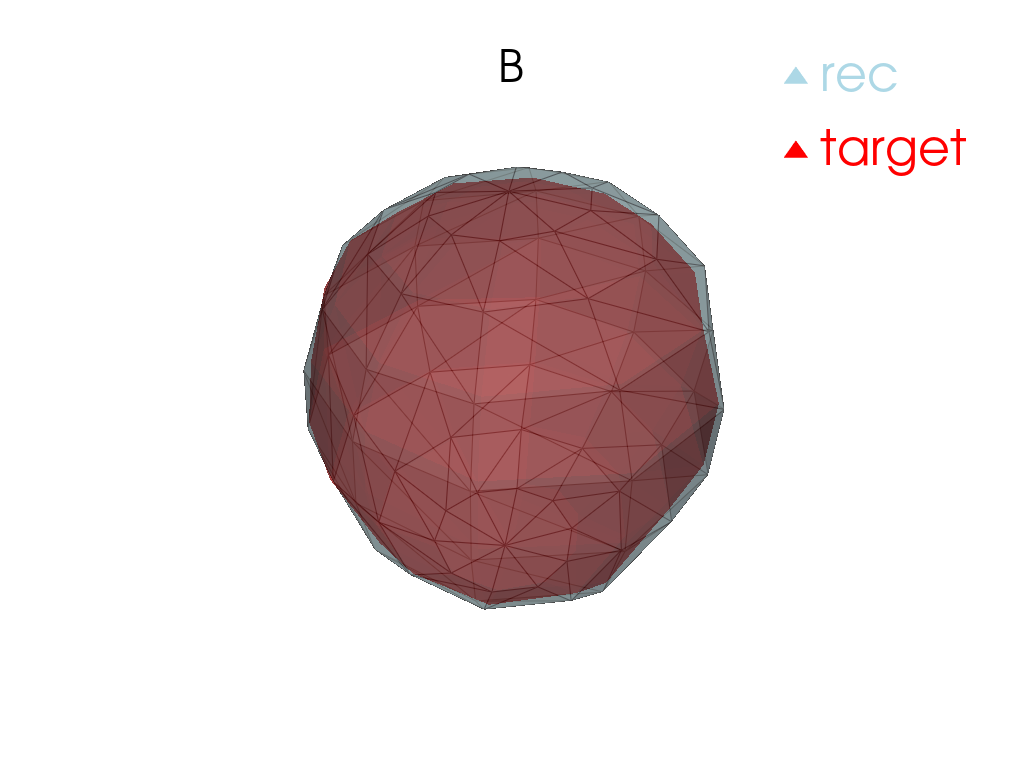

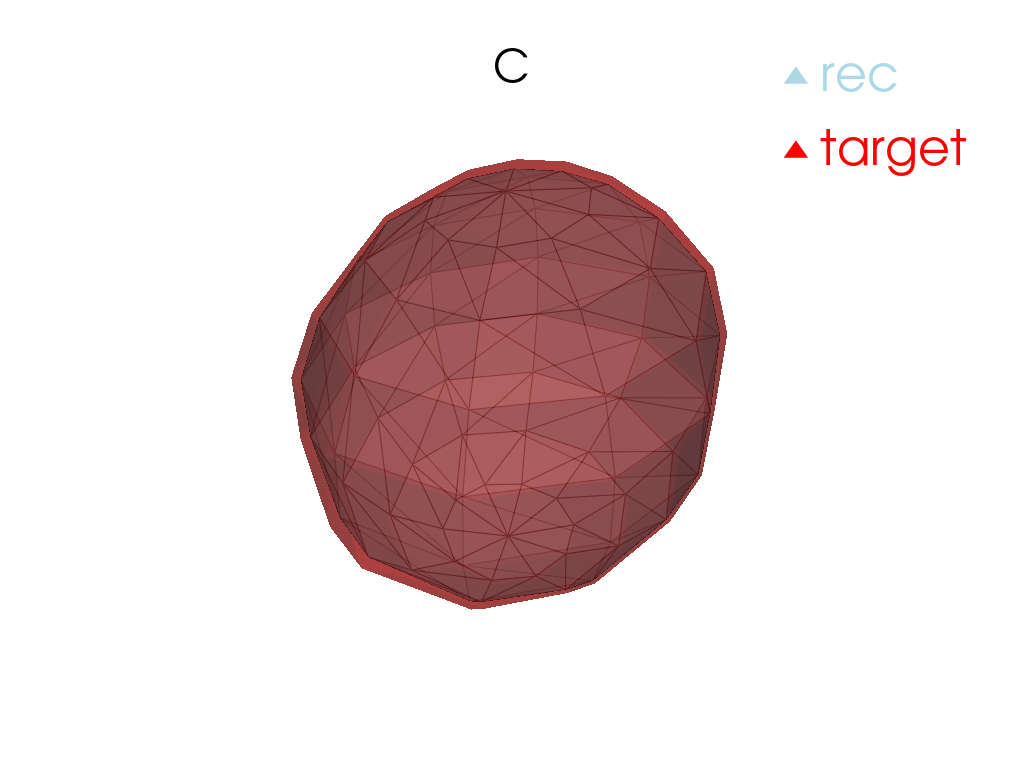

In [13]:
for point, reconstructed in zip(atlas_dir.points, atlas_dir.reconstructed()):
    pl = pv.Plotter()

    pl.add_mesh(
        reconstructed.as_pv(),
        show_edges=True,
        opacity=0.5,
        label="rec",
    )
    pl.add_mesh(
        point.as_pv(),
        opacity=0.5,
        color="red",
        label="target",
    )

    pl.add_title(point.id)
    pl.add_legend()

    pl.show()

Flow

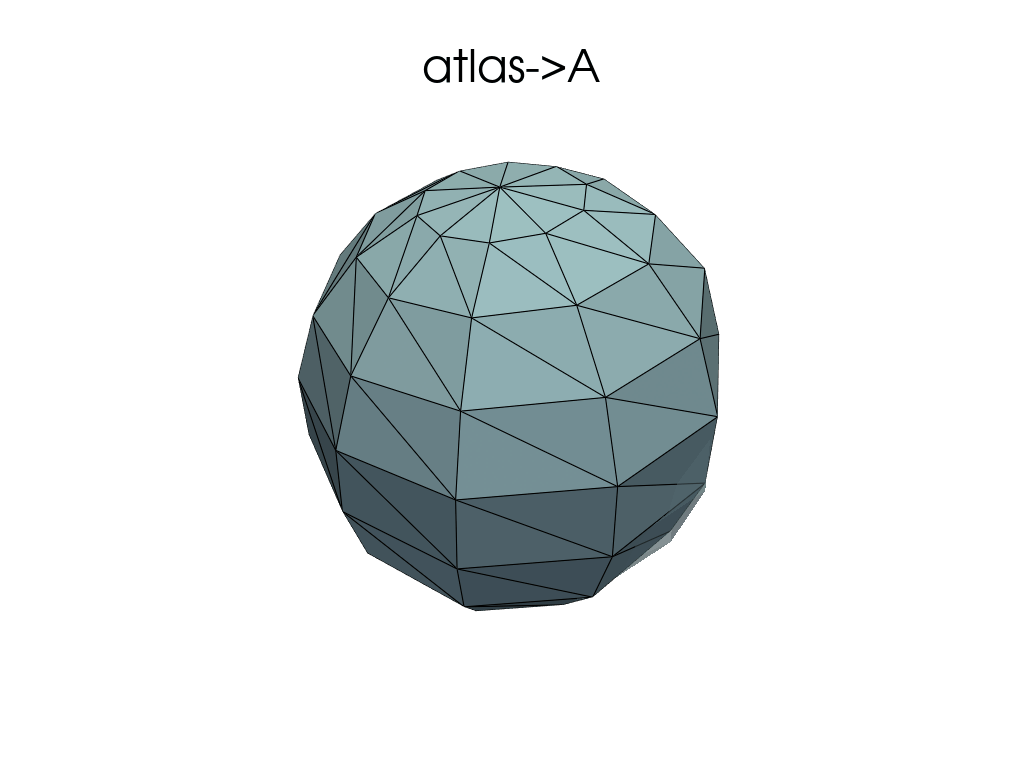

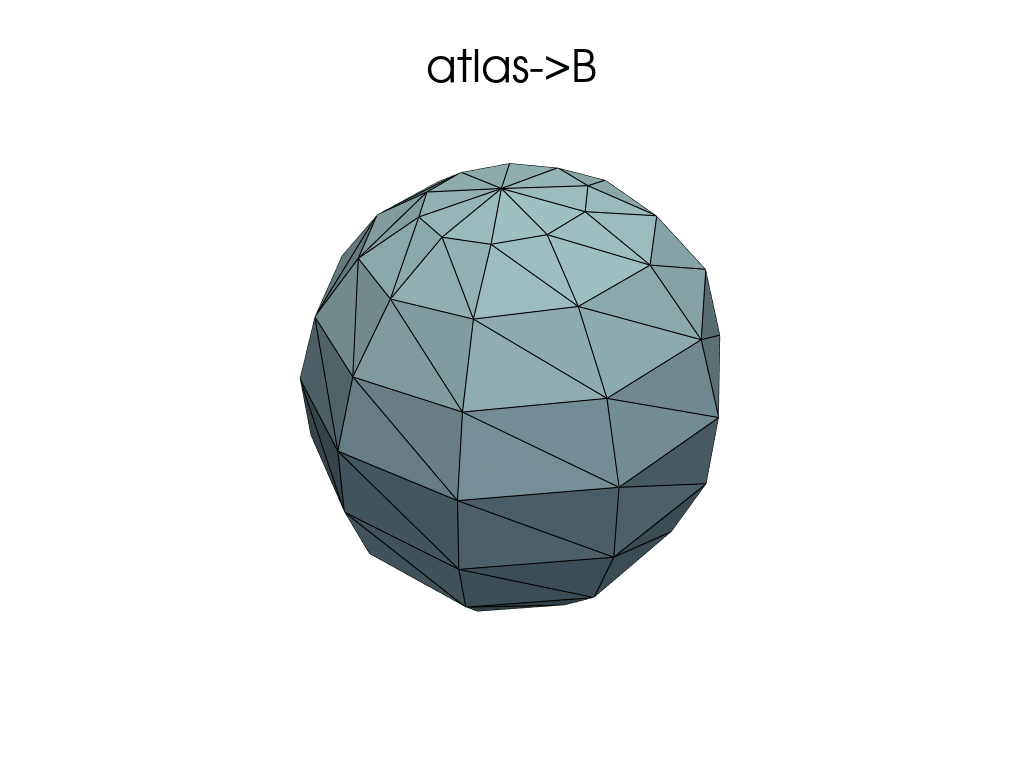

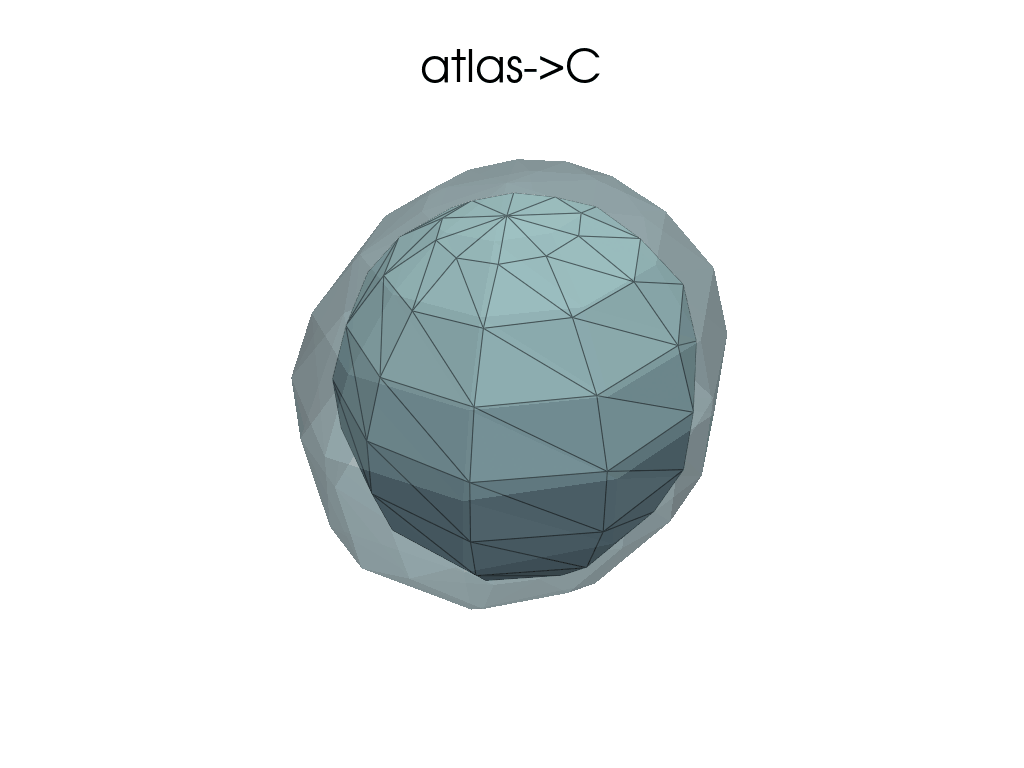

In [14]:
for point, flow in zip(atlas_dir.points, atlas_dir.flows()):
    pl = RegisteredMeshesGifPlotter()

    flow_meshes = [pt.as_pv() for pt in flow]

    pl.add_mesh(point.as_pv(), opacity=0.5)
    pl.add_title(f"atlas->{point.id}")

    pl.add_meshes(flow_meshes)

    pl.close()

    pl.show()

## Further reading

* [LDDMM: how to register a mesh to a template?](./deformetrica_register_mesh_template.ipynb)

* [LDDMM: how to do regression?](./lddmm_regression.ipynb)

* [LDDMM: how To Bring Deformations from Subject-Specific Atlases Into the Tangent Space at the Global Atlas](./lddmm_regression_across_subjects.ipynb)